In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import torch
from torch import nn
import copy
from scipy import ndimage
import torch.optim as optim
from tqdm.auto import tqdm
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.cm as cm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def generate_spiral_points(num_points=10000, noise=0.1):
    #Generates a 2D spiral, num_points: Number of particles, noise: The 'thickness' of the spiral
    
    # 1. Generate angles 
    theta = np.linspace(0, 3 * 2 * np.pi, num_points)
    
    # 2. Radius grows linearly with theta
    r = theta
    
    # 3. Convert polar to Cartesian (x, y)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    # 4. Add a bit of Gaussian thickness
    x += np.random.normal(0, noise, size=num_points)
    y += np.random.normal(0, noise, size=num_points)
    
    # 5. Normalization 
    x_norm = (x - np.mean(x)) / np.std(x)
    y_norm = (y - np.mean(y)) / np.std(y)
    
    return np.column_stack([x_norm, y_norm])

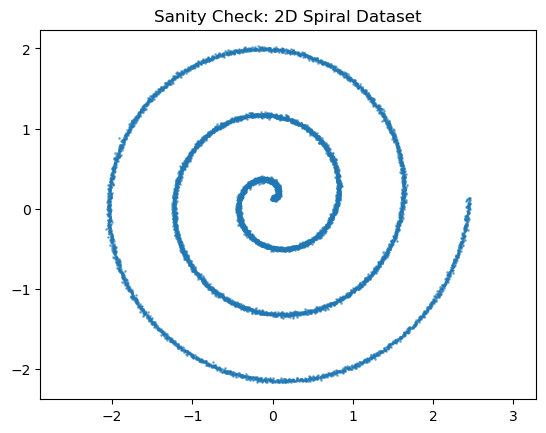

In [ ]:
# visual check
x_0_data = generate_spiral_points(10000)
x_0_tensor = torch.tensor(x_0_data, dtype=torch.float32).to(device)
plt.scatter(x_0_data[:, 0], x_0_data[:, 1], s=1, alpha=0.5)
plt.title("Sanity Check: 2D Spiral Dataset")
plt.axis('equal')
plt.show()

In [ ]:
# define useful stuff
class DiffusionScheduler:
    # controls the amount of noise at time steps    
    def __init__(self, steps=1000, beta_start=1e-4, beta_end=0.02,device='cpu'):
        self.steps = steps
        self.betas = torch.linspace(beta_start, beta_end, steps).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0).to(device)

    def add_noise(self, x_0, t):
        noise = torch.randn_like(x_0)
        sqrt_alphas_cumprod_t = self.alphas_cumprod[t].sqrt().view(-1, 1)
        sqrt_one_minus_alphas_cumprod_t = (1 - self.alphas_cumprod[t]).sqrt().view(-1, 1)
        
        x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
        return x_t, noise

class SinusoidalEmbedding(nn.Module):
    # Easier for model to keep track of time compared to representing it as scalar    
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        if t.ndim == 2: t = t.squeeze(-1)
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = (t * 1000)[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class FourierFeatures(nn.Module):
    # helps capture sharp edges of images
    def __init__(self, in_features, out_features, scale=2.0):
        super().__init__()
        W_init = torch.randn(in_features, out_features // 2) * scale
        self.register_buffer('W', W_init)

    def forward(self, x):
        x_proj = x @ self.W
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ResBlock(nn.Module):
    #helps gradient flow into earlier layers without the problem of vanishing gradient
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim)
        )
    def forward(self, x):
        return x + self.net(x)

In [ ]:
class DiffusionModel(nn.Module):
    def __init__(self, input_dim=2, time_dim=64, hidden_dim=512):
        super().__init__()
        self.coord_embed = FourierFeatures(input_dim, 64)
        self.time_mlp = nn.Sequential(
            SinusoidalEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )
        
        self.input_proj = nn.Linear(64 + time_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(4)])
        self.final_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t):
        x_emb = self.coord_embed(x)
        t_emb = self.time_mlp(t)
        
        h = self.input_proj(torch.cat([x_emb, t_emb], dim=-1))
        for block in self.res_blocks:
            h = block(h)
        return self.final_proj(h)

In [ ]:
# Pre-generate a fixed validation set
def create_val_set(x_0_tensor, scheduler, n_per_group=128):
    indices = torch.randint(0, len(x_0_tensor), (n_per_group * 3,))
    x_0_subset = x_0_tensor[indices]
    
    t_low = torch.randint(0, int(0.1 * scheduler.steps), (n_per_group,))
    t_mid = torch.randint(int(0.4 * scheduler.steps), int(0.6 * scheduler.steps), (n_per_group,))
    t_high = torch.randint(int(0.9 * scheduler.steps), scheduler.steps, (n_per_group,))
    
    t_val = torch.cat([t_low, t_mid, t_high]).to(device)
    x_t_val, noise_val = scheduler.add_noise(x_0_subset, t_val)
    
    return x_t_val, noise_val, t_val.float().view(-1, 1) / scheduler.steps

In [6]:
scheduler = DiffusionScheduler(steps=1000, device=device)

In [ ]:
val_x_t, val_noise, val_t_norm = create_val_set(x_0_tensor, scheduler)

In [ ]:
model = DiffusionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30000, eta_min=1e-5)

best_val_loss = float('inf')
best_model_state = None

print("Training Diffusion Model...")

# Wrap the range with tqdm for a live progress bar
pbar = tqdm(range(10001), desc="Training")

for epoch in pbar:
    model.train()
    optimizer.zero_grad()
    
    # batch sampling
    batch_indices = torch.randint(0, len(x_0_tensor), (512,))
    t = torch.randint(0, scheduler.steps, (512,))
    x_t, noise = scheduler.add_noise(x_0_tensor[batch_indices], t)
    
    # Forward pass and loss
    pred = model(x_t, t.float().view(-1, 1) / scheduler.steps)
    loss = nn.MSELoss()(pred, noise)
    
    # Backprop with gradient clipping
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    lr_scheduler.step()
    
    # Update progress bar with current training loss
    if epoch % 100 == 0:
        pbar.set_postfix({"train_loss": f"{loss.item():.4f}", "lr": f"{lr_scheduler.get_last_lr()[0]:.1e}"})
    
    # Validation checks
    if epoch % 1000 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(val_x_t, val_t_norm)
            val_loss = nn.MSELoss()(val_pred, val_noise).item()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
            
            # Using pbar.write prevents the bar from breaking when printing
            pbar.write(f"Step {epoch:5d} | Val Loss: {val_loss:.4f} {'(New Best!)' if best_val_loss == val_loss else ''}")

print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")

In [ ]:
# 4. SAMPLING
model.load_state_dict(best_model_state)

@torch.no_grad()
def sample(model, scheduler, num_samples=3000):
    model.eval()
    x = torch.randn(num_samples, 2)
    for i in reversed(range(scheduler.steps)):
        t_norm = torch.full((num_samples, 1), i / scheduler.steps)
        eps_theta = model(x, t_norm)
        
        alpha = scheduler.alphas[i]
        alpha_cumprod = scheduler.alphas_cumprod[i]
        beta = scheduler.betas[i]
        z = torch.randn_like(x) if i > 0 else 0
        
        x = (1 / alpha.sqrt()) * (x - (beta / (1 - alpha_cumprod).sqrt()) * eps_theta) + (beta.sqrt() * z)
        
    return x.numpy()

generated_points = sample(model, scheduler)

In [ ]:
plt.scatter(generated_points[:, 0], generated_points[:, 1], s=0.5, color='tab:green', alpha=0.5)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.title(f"Generated Distribution")
plt.show()

In [ ]:
@torch.no_grad()
def sample_with_history(model, scheduler, num_samples=2000, save_every=20):
    model.eval()
    device = next(model.parameters()).device
    x = torch.randn(num_samples, 2).to(device)
    
    history = []
    
    # Diffusion goes from T (pure noise) to 0 (clean data)
    for i in reversed(range(scheduler.steps)):
        t_norm = torch.full((num_samples, 1), i / scheduler.steps).to(device)
        eps_theta = model(x, t_norm)
        
        alpha = scheduler.alphas[i]
        alpha_cumprod = scheduler.alphas_cumprod[i]
        beta = scheduler.betas[i]
        z = torch.randn_like(x) if i > 0 else 0
        
        # The Reverse Diffusion Step
        x = (1 / alpha.sqrt()) * (x - (beta / (1 - alpha_cumprod).sqrt()) * eps_theta) + (beta.sqrt() * z)
        
        # =lip for stability
        x = torch.clamp(x, -5, 5)
        
        # Save snapshot
        if i % save_every == 0 or i == 0:
            history.append(x.cpu().numpy())
            
    return history # Returns a list of [num_samples, 2] arrays

In [ ]:
# 1. Capture the history 
history = sample_with_history(model, scheduler)

# 2. PAD THE HISTORY 
final_frame = history[-1]
padded_history = history + [final_frame] * 30  # Add few seconds of freeze

fig, ax = plt.subplots(figsize=(6, 6))
scat = ax.scatter([], [], s=1, color='tab:green', alpha=0.5)

def init():
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_title("Reverse Diffusion: Emerging Structure")
    return scat,

def update(frame):
    points = padded_history[frame] 
    scat.set_offsets(points)
    display_step = max(0, (len(history) - frame) * 20)
    ax.set_xlabel(f"Diffusion Step: {display_step}")
    return scat,

# 3. Create the animation using the padded list length
ani = FuncAnimation(fig, update, frames=len(padded_history), 
                    init_func=init, blit=True, repeat=False)

# 4. SAVE USING THE PILLOW WRITER OBJECT
writer = PillowWriter(fps=15, metadata=dict(loop=1)) 
ani.save('diffusion_spiral_1.gif', writer=writer)

plt.close()
print("Animation successfully saved with a 2-second freeze and no looping.")

In [ ]:
@torch.no_grad()
def sample_with_velocity(model, scheduler, num_samples=2000, save_every=20):
    model.eval()
    device = next(model.parameters()).device
    x = torch.randn(num_samples, 2).to(device)
    
    history = []
    velocities = []
    
    for i in reversed(range(scheduler.steps)):
        x_old = x.clone() # Store position before the move
        
        t_norm = torch.full((num_samples, 1), i / scheduler.steps).to(device)
        eps_theta = model(x, t_norm)
        
        alpha = scheduler.alphas[i]
        alpha_cumprod = scheduler.alphas_cumprod[i]
        beta = scheduler.betas[i]
        z = torch.randn_like(x) if i > 0 else 0
        
        # The Reverse Diffusion Step
        x = (1 / alpha.sqrt()) * (x - (beta / (1 - alpha_cumprod).sqrt()) * eps_theta) + (beta.sqrt() * z)
        
        if i % save_every == 0 or i == 0:
            # Calculate L2 distance moved (Velocity)
            v = torch.norm(x - x_old, dim=1).cpu().numpy()
            history.append(x.cpu().numpy())
            velocities.append(v)
            
    return history, velocities

In [ ]:
history, velocities = sample_with_velocity(model, scheduler)

# Pad both lists for the brief freeze
final_frame = history[-1]
final_v = np.zeros_like(velocities[-1]) # Velocity is zero at the end
padded_history = history + [final_frame] * 30
padded_velocities = velocities + [final_v] * 30

fig, ax = plt.subplots(figsize=(7, 6))
all_v = np.concatenate(velocities)
dynamic_vmax = np.percentile(all_v, 95) 

print(f"95th percentile velocity: {dynamic_vmax:.4f}")


scat = ax.scatter([], [], s=2, cmap='magma', vmin=0, vmax=dynamic_vmax, c = []) 
plt.colorbar(scat, ax=ax, label='Step Velocity (Displacement)')

def init():
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_title("Reverse Diffusion: Velocity Map")
    return scat,

def update(frame):
    points = padded_history[frame]
    v_values = padded_velocities[frame]
    
    scat.set_offsets(points)
    scat.set_array(v_values) # This updates the colors!
    
    display_step = max(0, (len(history) - frame) * 20)
    ax.set_xlabel(f"Diffusion Step: {display_step}")
    return scat,

ani = FuncAnimation(fig, update, frames=len(padded_history), 
                    init_func=init, blit=True, repeat=False)

# Save with the Pillow writer as before
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=15, metadata=dict(loop=1))
ani.save('diffusion_velocity.gif', writer=writer)

In [ ]:
def generate_circle_points(num_points=5000, noise=0.05, radius=1.2):
    theta = np.linspace(0, 2 * np.pi, num_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    
    # Add noise
    x += np.random.normal(0, noise, size=num_points)
    y += np.random.normal(0, noise, size=num_points)
    
    # normalize
    x_norm = (x - np.mean(x)) / (np.std(x) + 1e-6)
    y_norm = (y - np.mean(y)) / (np.std(y) + 1e-6)
    
    return np.column_stack([x_norm, y_norm])

In [13]:
def generate_infinity(num_points=5000, noise=0.03):
    t = np.linspace(0, 2 * np.pi, num_points)
    denom = 1 + np.sin(t)**2
    x = np.cos(t) / denom
    y = np.sin(t) * np.cos(t) / denom
    
    # Add noise and normalize
    res = np.column_stack([x, y])
    res += np.random.normal(0, noise, size=res.shape)
    return (res - np.mean(res, axis=0)) / np.std(res)

In [ ]:
def generate_lissajous(num_points=5000, a=3, b=2, delta=np.pi/2, noise=0.02):
    t = np.linspace(0, 2 * np.pi, num_points)
    x = np.sin(a * t + delta)
    y = np.sin(b * t)
    
    res = np.column_stack([x, y])
    res += np.random.normal(0, noise, size=res.shape)
    return res 

In [ ]:
def generate_moons(num_points=5000, noise=0.05):
    points, _ = make_moons(n_samples=num_points, noise=noise)
    return (points - np.mean(points, axis=0)) / np.std(points)

In [ ]:
def generate_astroid(num_points=5000, noise=0.02):
    t = np.linspace(0, 2 * np.pi, num_points)
    x = np.cos(t)**3
    y = np.sin(t)**3
    
    res = np.column_stack([x, y])
    res += np.random.normal(0, noise, size=res.shape)
    return res * 2 

In [ ]:
def create_val_set_with_labels(x_0_tensor, labels_tensor, scheduler, n_per_group=128):
    device = x_0_tensor.device
    indices = torch.randint(0, len(x_0_tensor), (n_per_group * 3,), device=device)
    
    x_0_subset = x_0_tensor[indices]
    val_labels = labels_tensor[indices] 
    
    t_val = torch.cat([
        torch.randint(0, int(0.1 * scheduler.steps), (n_per_group,)),
        torch.randint(int(0.4 * scheduler.steps), int(0.6 * scheduler.steps), (n_per_group,)),
        torch.randint(int(0.9 * scheduler.steps), scheduler.steps, (n_per_group,))
    ]).to(device) 
    
    x_t_val, noise_val = scheduler.add_noise(x_0_subset, t_val)
    return x_t_val, noise_val, t_val.float().view(-1, 1) / scheduler.steps, val_labels

In [ ]:
class ConditionalDiffusionModel(nn.Module):
    def __init__(self, input_dim=2, time_dim=64, label_dim=64, num_classes=2, hidden_dim=512):
        super().__init__()
        self.coord_embed = FourierFeatures(input_dim, 64)
        self.time_mlp = nn.Sequential(
            SinusoidalEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )
        
        # Label Embedding layer
        self.label_embed = nn.Embedding(num_classes, label_dim)
        
        self.input_proj = nn.Linear(64 + time_dim + label_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(4)])
        self.final_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t, labels):
        x_emb = self.coord_embed(x)
        t_emb = self.time_mlp(t)
        l_emb = self.label_embed(labels) # Get the 'Spiral-ness' or 'Circle-ness' vector
        
        # Concatenate all three inputs
        h = self.input_proj(torch.cat([x_emb, t_emb,l_emb], dim=-1))
        
        for block in self.res_blocks:
            h = block(h)
        return self.final_proj(h)

In [ ]:
model = ConditionalDiffusionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30000, eta_min=1e-5)

best_val_loss = float('inf')
best_model_state = None

print("Training labelled Diffusion Model...")

# Wrap the range with tqdm for a live progress bar
pbar = tqdm(range(20001), desc="Training")

# Prepare mixed data
spiral_data = generate_spiral_points(10000)
#infinity_data = generate_infinity(10000)
circle_data = generate_circle_points(10000)
#double_circle_data = generate_moons(10000)


x_0_data = np.vstack([spiral_data, double_circle_data])
# Labels: 0 for first 10000, 1 for next 10000
labels_data = np.array([0]*10000 + [1]*10000)

# Convert to tensors

x_0_tensor = torch.tensor(x_0_data, dtype=torch.float32).to(device)
labels_tensor = torch.tensor(labels_data, dtype=torch.long).to(device)
val_x_t, val_noise, val_t_norm, val_labels = create_val_set_with_labels(x_0_tensor, labels_tensor, scheduler)


Training labelled Diffusion Model...


Training:   0%|          | 0/20001 [00:00<?, ?it/s]

In [ ]:

#  Training Loop
for epoch in pbar:
    model.train()
    optimizer.zero_grad()
    
    batch_indices = torch.randint(0, len(x_0_tensor), (512,))
    batch_x = x_0_tensor[batch_indices]
    batch_labels = labels_tensor[batch_indices] 
    
    t = torch.randint(0, scheduler.steps, (512,)).to(device)
    x_t, noise = scheduler.add_noise(batch_x, t)

    # Forward pass and loss
    pred = model(x_t, t.float().view(-1, 1) / scheduler.steps, batch_labels)
    loss = nn.MSELoss()(pred, noise)
    
    # Backprop with gradient clipping
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    lr_scheduler.step()
    
    # Update progress bar with current training loss
    if epoch % 100 == 0:
        pbar.set_postfix({"train_loss": f"{loss.item():.4f}", "lr": f"{lr_scheduler.get_last_lr()[0]:.1e}"})
    
    # Validation checks
    if epoch % 1000 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(val_x_t, val_t_norm, val_labels)
            val_loss = nn.MSELoss()(val_pred, val_noise).item()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
            
            # Using pbar.write prevents the bar from breaking when printing
            pbar.write(f"Step {epoch:5d} | Val Loss: {val_loss:.4f} {'(New Best!)' if best_val_loss == val_loss else ''}")

print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")

Step     0 | Val Loss: 3.9764 (New Best!)
Step  1000 | Val Loss: 0.3711 (New Best!)
Step  2000 | Val Loss: 0.3434 (New Best!)
Step  3000 | Val Loss: 0.3400 (New Best!)
Step  4000 | Val Loss: 0.3423 
Step  5000 | Val Loss: 0.3505 
Step  6000 | Val Loss: 0.3540 
Step  7000 | Val Loss: 0.3282 (New Best!)
Step  8000 | Val Loss: 0.3332 
Step  9000 | Val Loss: 0.3343 
Step 10000 | Val Loss: 0.3302 
Step 11000 | Val Loss: 0.3278 (New Best!)
Step 12000 | Val Loss: 0.3315 
Step 13000 | Val Loss: 0.3270 (New Best!)
Step 14000 | Val Loss: 0.3323 
Step 15000 | Val Loss: 0.3338 
Step 16000 | Val Loss: 0.3271 
Step 17000 | Val Loss: 0.3289 
Step 18000 | Val Loss: 0.3230 (New Best!)
Step 19000 | Val Loss: 0.3241 
Step 20000 | Val Loss: 0.3234 

Training complete. Best Val Loss: 0.3230


In [ ]:
@torch.no_grad()
def sample_conditional_with_velocity(model, scheduler, label_id, num_samples=2000, save_every=20):
    model.eval()
    device = next(model.parameters()).device
    x = torch.randn(num_samples, 2).to(device)
    
    labels = torch.full((num_samples,), label_id, dtype=torch.long).to(device)
    
    history = []
    velocities = []
    
    for i in reversed(range(scheduler.steps)):
        x_old = x.clone()
        
        t_norm = torch.full((num_samples, 1), i / scheduler.steps).to(device)
        
        eps_theta = model(x, t_norm, labels)
        
        alpha = scheduler.alphas[i]
        alpha_cumprod = scheduler.alphas_cumprod[i]
        beta = scheduler.betas[i]
        z = torch.randn_like(x) if i > 0 else 0
        
        x = (1 / alpha.sqrt()) * (x - (beta / (1 - alpha_cumprod).sqrt()) * eps_theta) + (beta.sqrt() * z)
        
        if i % save_every == 0 or i == 0:
            v = torch.norm(x - x_old, dim=1).cpu().numpy()
            history.append(x.cpu().numpy())
            velocities.append(v)
            
    return history, velocities

In [ ]:
# Generate history for both classes
h_spiral, v_spiral = sample_conditional_with_velocity(model, scheduler, label_id=0)
h_circle, v_circle = sample_conditional_with_velocity(model, scheduler, label_id=1)

# Pad for the brief freeze
pad_len = 30
padded_h_spiral = h_spiral + [h_spiral[-1]] * pad_len
padded_h_circle = h_circle + [h_circle[-1]] * pad_len
# Use zeros for velocity during freeze
padded_v_spiral = v_spiral + [np.zeros_like(v_spiral[-1])] * pad_len
padded_v_circle = v_circle + [np.zeros_like(v_circle[-1])] * pad_len

# Set up side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
vmax = np.percentile(np.concatenate(v_spiral + v_circle), 95)

scat1 = ax1.scatter([], [], s=2, cmap='magma', vmin=0, vmax=vmax, c=[])
scat2 = ax2.scatter([], [], s=2, cmap='magma', vmin=0, vmax=vmax, c=[])

cbar = fig.colorbar(scat1, ax=[ax1, ax2], location='right', pad=0.05)
cbar.set_label('Step Velocity (Score Magnitude)', rotation=270, labelpad=15)
#fig.subplots_adjust(top=0.85, wspace=0.3)
def init():
    for ax, title in zip([ax1, ax2], ["Label 0: Spiral", "Label 1: Circle"]):
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_title(title)
    return scat1, scat2

def update(frame):
    # Update Spiral
    scat1.set_offsets(padded_h_spiral[frame])
    scat1.set_array(padded_v_spiral[frame])
    
    # Update Circle
    scat2.set_offsets(padded_h_circle[frame])
    scat2.set_array(padded_v_circle[frame])
    
    display_step = max(0, (len(h_spiral) - frame) * 20)
    fig.suptitle(f"Conditional Diffusion Steps Remaining: {display_step}")
    return scat1, scat2

ani = FuncAnimation(fig, update, frames=len(padded_h_spiral), 
                    init_func=init, blit=True, repeat=False)

writer = PillowWriter(fps=15, metadata=dict(loop=1))
ani.save('conditional_comparison.gif', writer=writer)
plt.close()